## Task 2

Color coded scatter plot

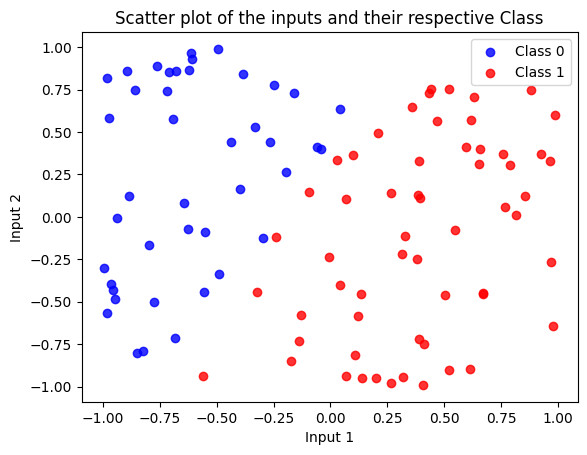

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed((42))

data = np.loadtxt("2d_classification_single_neuron.csv", delimiter=",")
input1 = data[:, 0]
input2 = data[:, 1]
labels = data[:, 2]

for class_value, color, label in zip([0, 1], ['blue', 'red'], ['Class 0', 'Class 1']):
    idx = labels == class_value
    plt.scatter(input1[idx], input2[idx], color=color, label=label, alpha=0.8)

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Scatter plot of the inputs and their respective Class")
plt.legend()
plt.show()

## Multi dimensional input Neuron

In [3]:
class Neuron:
    def __init__(self, input_dim):
        self.weight_matrix = np.random.randn(input_dim)
        self.bias = np.random.randn()

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def squared_error(self, y_true: float, y_pred: float):
        return (y_true - y_pred) ** 2

    def output_function(self, x):
        return self.sigmoid(x @ self.weight_matrix + self.bias)

    def update(self, x, y_true: float, y_pred: float, eta):
        dE_dy_pred = self.dE_dy_pred(y_true, y_pred)
        dy_pred_dw = self.dy_pred_dw(x, y_pred)
        dy_pred_db = self.dy_pred_db(y_pred)

        dE_dw = dE_dy_pred * dy_pred_dw
        dE_db = dE_dy_pred * dy_pred_db

        self.weight_matrix -= eta * dE_dw
        self.bias -= eta * dE_db

    def dE_dy_pred(self, y_true, y_pred):
        return -2 * (y_true - y_pred)

    def dy_pred_dw(self, x, y_pred):
        return y_pred * (1 - y_pred) * x

    def dy_pred_db(self, y_pred):
        return y_pred * (1 - y_pred)

## Scatter plot

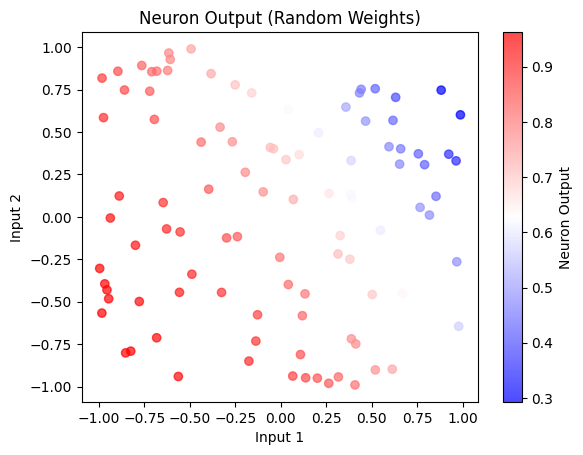

In [4]:
inputs = np.column_stack((input1, input2))
neuron = Neuron(input_dim=inputs.shape[1])
outputs = np.array([neuron.output_function(x) for x in inputs])

plt.scatter(data[:, 0], data[:, 1], c=outputs, cmap='bwr', alpha=0.7)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Neuron Output (Random Weights)")
plt.colorbar(label="Neuron Output")
plt.show()

## Updated code and training

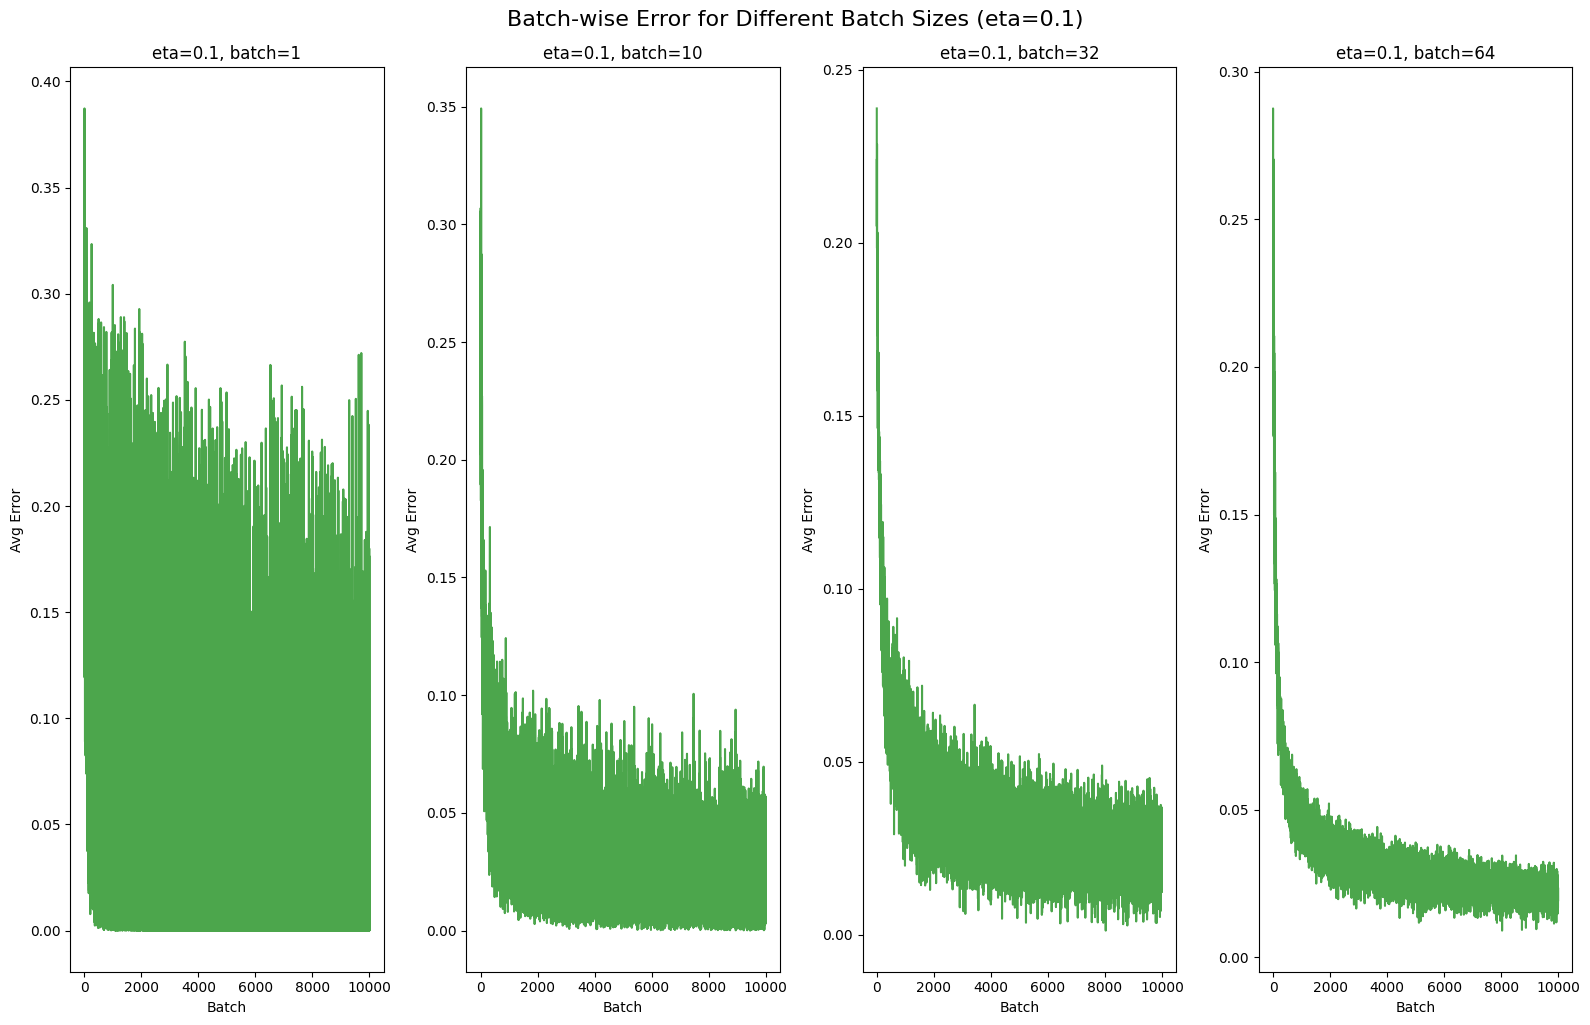

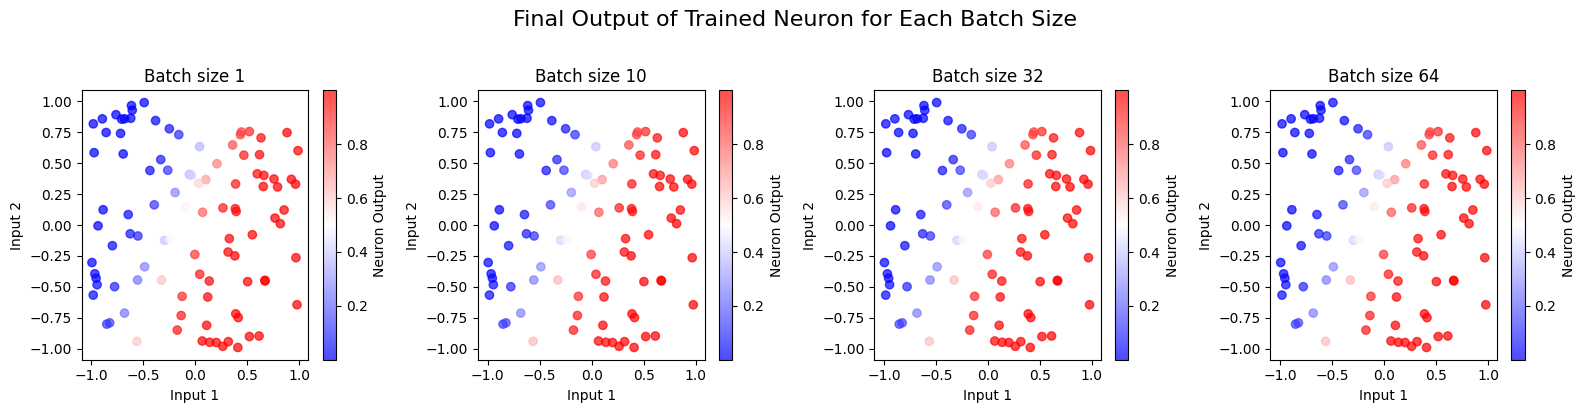

In [ ]:
learning_rate = 0.1
batch_sizes = [1, 10, 32, 64]
n_batches = 10000
n_samples = len(inputs)
rng = np.random.default_rng()
plt.figure(figsize=(16, 10))

eta = 0.1
final_neurons = []
for j, batch_size in enumerate(batch_sizes):
    new_neuron = Neuron(input_dim=inputs.shape[1])
    errors = []
    for batch in range(n_batches):
        idxs = rng.choice(n_samples, size=batch_size, replace=False)
        batch_x = inputs[idxs]
        batch_y = labels[idxs]
        batch_error = 0
        sum_dE_dw = 0
        sum_dE_db = 0
        for x, y_true in zip(batch_x, batch_y):
            y_pred = new_neuron.output_function(x)
            error = new_neuron.squared_error(y_true, y_pred)
            batch_error += error
            dE_dy_pred = new_neuron.dE_dy_pred(y_true, y_pred)
            dy_pred_dw = new_neuron.dy_pred_dw(x, y_pred)
            dy_pred_db = new_neuron.dy_pred_db(y_pred)
            sum_dE_dw += dE_dy_pred * dy_pred_dw
            sum_dE_db += dE_dy_pred * dy_pred_db
        avg_dE_dw = sum_dE_dw / batch_size
        avg_dE_db = sum_dE_db / batch_size
        new_neuron.weight_matrix -= eta * avg_dE_dw
        new_neuron.bias -= eta * avg_dE_db
        errors.append(batch_error / batch_size)
    plt.subplot(1, len(batch_sizes), j + 1)
    plt.plot(errors, color="green", alpha=0.7)
    plt.title(f"eta={eta}, batch={batch_size}")
    plt.xlabel("Batch")
    plt.ylabel("Avg Error")
    plt.tight_layout()
    final_neurons.append(new_neuron)
plt.suptitle("Batch-wise Error for Different Batch Sizes (eta=0.1)", fontsize=16, y=1.02)
plt.show()

plt.figure(figsize=(16, 4))
for j, (batch_size, neuron) in enumerate(zip(batch_sizes, final_neurons)):
    outputs = np.array([neuron.output_function(x) for x in inputs])
    plt.subplot(1, len(batch_sizes), j + 1)
    plt.scatter(data[:, 0], data[:, 1], c=outputs, cmap='bwr', alpha=0.7)
    plt.title(f"Batch size {batch_size}")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.colorbar(label="Neuron Output")
plt.suptitle("Final Output of Trained Neuron for Each Batch Size", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()